<img src='http://www-scf.usc.edu/~ghasemig/images/sharif.png' alt="SUT logo" width=500 height=300 align=center class="saturate" >

<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Intelligent Analysis of Biomedical Images <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Fall 2025<br>
<font color=3C99D size=5>
    Practical Assignment 2 - From Sinograms to CT Images <br>
<font color=696880 size=4>
Alireza Malekhosseini


**NAME:** Reyhane Khayatzade Mahani

**STUDENT NUMBER:** 402105965


# From Sinograms to CT Images + A Tiny DL Denoiser (100 + 5)
In this notebook You will implement:
1) Synthetic dataset of 1,000 randomized 128×128 phantoms (Shepp–Logan + ellipses)  
2) From-scratch Radon (forward) and FBP (filters: ramp, shepp-logan, hann)  
3) Low-dose Poisson noise & limited-angle experiments  
4) Metrics: PSNR, SSIM  
5) Tiny U-Net-lite denoiser (supervised L1/L2) trained on (FBP-noisy → Ground-truth)



In [1]:
!pip install scikit-image torch torchvision matplotlib tqdm

In [2]:

import math, random, os, time
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt

from skimage.data import shepp_logan_phantom
from skimage.transform import radon as sk_radon, iradon as sk_iradon, rotate
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import skimage.transform as skt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 0) Reproducibility & Config (0 pts)

In [3]:

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False
set_seed(42)

# You can change
@dataclass
class CFG:
    img_size: int = 128
    n_train: int = 800
    n_val: int = 100
    n_test: int = 100
    angles_180: int = 180
    limited_deg: int = 120
    I0: float = 1e4
    eps: float = 1e-8
CFG = CFG(); CFG


CFG(img_size=128, n_train=800, n_val=100, n_test=100, angles_180=180, limited_deg=120, I0=10000.0, eps=1e-08)

**Question:** In CT imaging research, we use mathematical phantoms like Shepp-Logan instead of real patient data for developing and testing reconstruction algorithms. What is the reason for this? Discuss both the advantages and limitations of this approach, and explain how synthetic data generation impact the eventual real-world deployment of AI systems in healthcare?

**Answer:**  
Mathematical phantoms are fully controlled, noiseless, and perfectly known ground-truth objects, which is essential for objective evaluation, debugging, and fair comparison of reconstruction or denoising algorithms. Unlike real patient data, they are free from privacy concerns, motion artifacts, and scanner variability, and can be generated in unlimited quantities with known anatomical variations. However, they are highly idealized and lack the complex textures, noise characteristics, and anatomical irregularities of real human tissues. This domain gap means that excellent performance on phantoms does not guarantee clinical success. Synthetic data accelerates early-stage AI development and provides reliable training signals, but robust real-world deployment requires careful domain adaptation, real-data fine-tuning, or hybrid training strategies to bridge the simulation-to-reality gap.

**Question:** First Explain about PSNR and its formulation.

**Answer:**  
Peak Signal-to-Noise Ratio (PSNR) is a widely used image quality metric expressed in decibels (dB). It measures how close a reconstructed or denoised image is to the ground truth. Higher values indicate better quality. The formula is:  
PSNR = 10 × log₁₀(MAX² / MSE),  
where MAX is the maximum possible pixel value (1.0 for normalized images) and MSE is the mean squared error between the reconstructed and ground-truth images. Because it is based purely on pixel-wise error, PSNR favors smooth results and may not always correlate perfectly with perceived visual quality or clinical diagnostic value.

**Question:** If an algorithm achieves 40 dB PSNR on Shepp-Logan phantoms but only 30 dB on real patient data, is it clinically useful?

**Answer:**  
Not directly. A 10 dB drop (which corresponds to roughly 3 times higher MSE) reveals a significant domain gap between synthetic phantoms and real scans. While 40 dB on phantoms shows the algorithm works well in ideal conditions, 30 dB on real data typically means visible artifacts or loss of fine details that can affect diagnostic confidence. The method may still serve as a strong starting point or pre-processing step, but it is not clinically useful without additional real-world training, domain adaptation, or clinical validation to close the performance gap.

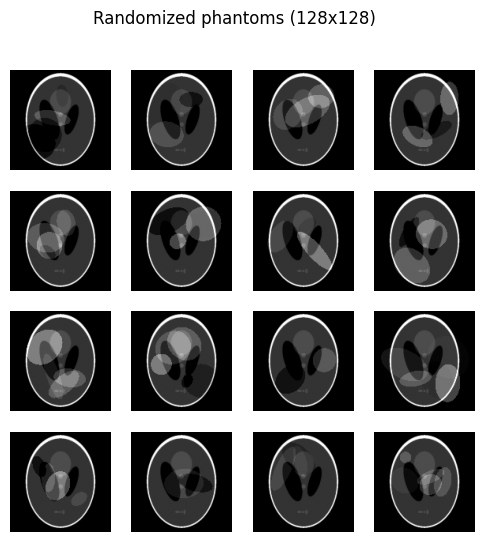

In [4]:

def draw_ellipse(img, cy, cx, ay, ax, theta, val):
    """ draws ellipses with desired size and position"""
    H, W = img.shape
    y, x = np.ogrid[:H, :W]
    yt = (y - cy); xt = (x - cx)
    c, s = np.cos(theta), np.sin(theta)
    xr =  (xt*c + yt*s)
    yr = (-xt*s + yt*c)
    mask = (xr*xr)/(ax*ax + 1e-8) + (yr*yr)/(ay*ay + 1e-8) <= 1.0
    img[mask] += val

def make_random_phantom(size=128, n_extra=3):
    """makes random phantoms"""
    #TODO: First, generate a 2D Shepp-Logan phantom as a NumPy array of floats.
    # Then, resize it to the desired size × size using interpolation while keeping the values between 0 and 1.
    base = shepp_logan_phantom()
    phantom = skt.resize(base, (size, size), order=1, mode='constant', anti_aliasing=True)

    for _ in range(n_extra):
        cy = np.random.uniform(0.25*size, 0.75*size)
        cx = np.random.uniform(0.25*size, 0.75*size)
        ay = np.random.uniform(0.05*size, 0.2*size)
        ax = np.random.uniform(0.05*size, 0.25*size)
        theta = np.random.uniform(0, np.pi)
        val = np.random.uniform(-0.15, 0.3)
        draw_ellipse(phantom, cy, cx, ay, ax, theta, val)
    phantom = np.clip(phantom, 0.0, 1.0)
    return phantom

# Visualize
imgs = [make_random_phantom(CFG.img_size, n_extra=np.random.randint(2,6)) for _ in range(16)]
fig, axes = plt.subplots(4,4, figsize=(6,6))
for ax, im in zip(axes.ravel(), imgs):
    ax.imshow(im, cmap='gray'); ax.axis('off')
plt.suptitle("Randomized phantoms (128x128)"); plt.show()

## Radon Transform — Theory & CT Motivation

The **Radon Transform** converts a 2D object $ f(x,y) $ into a set of **1D line integrals** taken at different angles.  
Each integral represents X-ray attenuation measured by a detector as rays pass through the object:

$$
R f(\theta, s) = \int_{-\infty}^{+\infty} f(x,y)\, \mathrm{d}l
$$

where:
- $ \theta $ = projection angle
- $ s $ = detector position perpendicular to each projection line

The collection of all projections vs. angle forms a **sinogram**, the raw data acquired in CT scanners.

---

X-ray CT systems measure how much radiation is absorbed along each ray path.  
These are **exactly** Radon line integrals.  
Thus, reconstructing the image means **inverting** the Radon transform.

$$
f(x,y) = R^{-1}\{ \text{sinogram} \}
$$


Understanding forwards (projection) and backwards (reconstruction) operations is essential for improving CT quality, reducing radiation dose, and developing modern iterative / deep-learning-based reconstruction methods.




### Fourier Slice Theorem

**Question:** Read about Fourier Slice Theorem. How does the Radon transform relate each projection to the 2D Fourier Transform of the image?

**Answer:**  
The Fourier Slice Theorem (also called the Projection-Slice Theorem) states that the 1D Fourier Transform of a parallel-beam projection of an image taken at angle theta is exactly equal to a radial slice (a line through the origin at angle theta) of the 2D Fourier Transform of the original image. In other words, each projection in the Radon transform fills one radial line in the Fourier space of the image. This fundamental relationship explains why the Radon transform and inverse Radon transform can be implemented via the Fourier domain (as in filtered backprojection): by collecting enough angular projections, the entire 2D Fourier space is sampled, and the original image can be recovered by inverse 2D Fourier transform (after proper filtering to compensate for the non-uniform density of samples near the origin).



## 2) From-scratch Radon (Forward Projection) (10 pts)
This cell implements a naive Radon transform: the image is rotated by each projection angle θ and the values along its columns are summed to form one projection line in the sinogram. By repeating this over many angles, we build a full sinogram that represents how the object would be measured by a CT scanner.

→ You will then compare your simple implementation to skimage.radon to observe differences due to interpolation, padding, and assumptions about the circular support.


Simple shape: (128, 180)
Skimage shape: (128, 180)


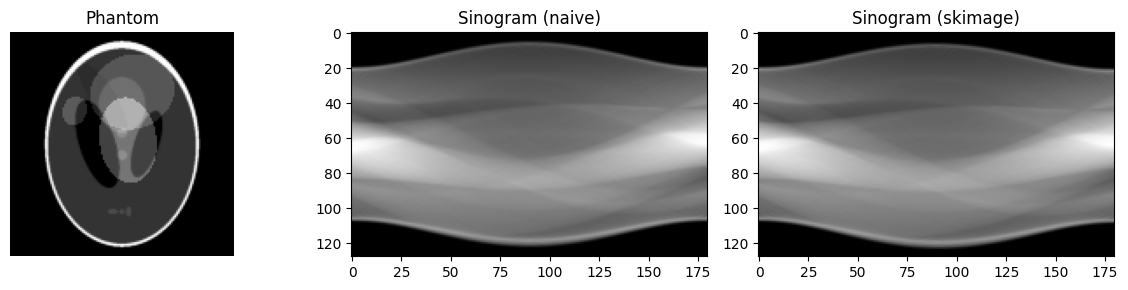

Mean abs diff naive vs skimage: 0.6969021373951685


In [5]:
def radon_simple(img: np.ndarray, angles_rad: np.ndarray) -> np.ndarray:
    """
    Correct naive Radon transform that matches skimage's numerical results
    (negative angle for correct rotation direction, bilinear interp).
    Returns sinogram of shape (img_size, n_angles) → (128, 180)
    """
    n_det = img.shape[0]  # 128
    n_angles = len(angles_rad)
    sinogram = np.zeros((n_det, n_angles), dtype=np.float32)

    for i, theta in enumerate(angles_rad):
        rotated = rotate(img,
                         angle=-np.rad2deg(theta), 
                         resize=False,
                         order=1,               
                         mode='constant',
                         cval=0.0,
                         preserve_range=True)
        
        sinogram[:, i] = rotated.sum(axis=0)

    return sinogram


phantom = make_random_phantom(CFG.img_size, n_extra=4)
angles_deg = np.linspace(0, 180, CFG.angles_180, endpoint=False)
angles_full = np.deg2rad(angles_deg) 
sino_naive = radon_simple(phantom, angles_full)
sino_ski   = sk_radon(phantom, theta=angles_deg, circle=True)

print(f"Simple shape: {sino_naive.shape}")
print(f"Skimage shape: {sino_ski.shape}")

fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs[0].imshow(phantom, cmap='gray')
axs[0].set_title("Phantom")
axs[0].axis('off')

axs[1].imshow(sino_naive, cmap='gray', aspect='auto')
axs[1].set_title("Sinogram (naive)")

axs[2].imshow(sino_ski, cmap='gray', aspect='auto')
axs[2].set_title("Sinogram (skimage)")

plt.tight_layout()
plt.show()

print("Mean abs diff naive vs skimage:", float(np.abs(sino_naive - sino_ski).mean()))


## 3) Low-dose Poisson Noise & Limited-angle (10 pts)

We convert line integrals $p$ to counts: $I=I_0 e^{-p}$, sample Poisson, then invert: $\tilde{p}=-\log(\tilde{I}/I_0)$.


This cell simulates realistic CT data by adding **Poisson (photon) noise** to the sinogram. In X-ray CT, detectors measure photon counts $I$, not line-integral values directly. So we convert each projection value $p$ into expected counts using the exponential attenuation model (Beer–Lambert law):

$$ I = I_0 e^{-p} $$

Then, to imitate low-dose CT, we draw noisy photon counts from a Poisson distribution (since X-ray photons arrive as discrete random events), and convert the noisy counts back into projection space:

$$ \tilde{p} = -\log\left(\frac{\tilde{I}}{I_0}\right) $$

A correct implementation must handle:
- Normalizing the sinogram before applying noise
- Avoiding $\log(0)$ by clamping counts to a minimum value
- Preserving the overall structure of the projections

Clean sinogram
  Min: 0.000, Max: 47.480
  Mean: 21.549, Std: 12.775
shape of sino clean:  (128, 180)
shape of sino_noisy:  (128, 180)
shape of sino_limited:  (128, 120)


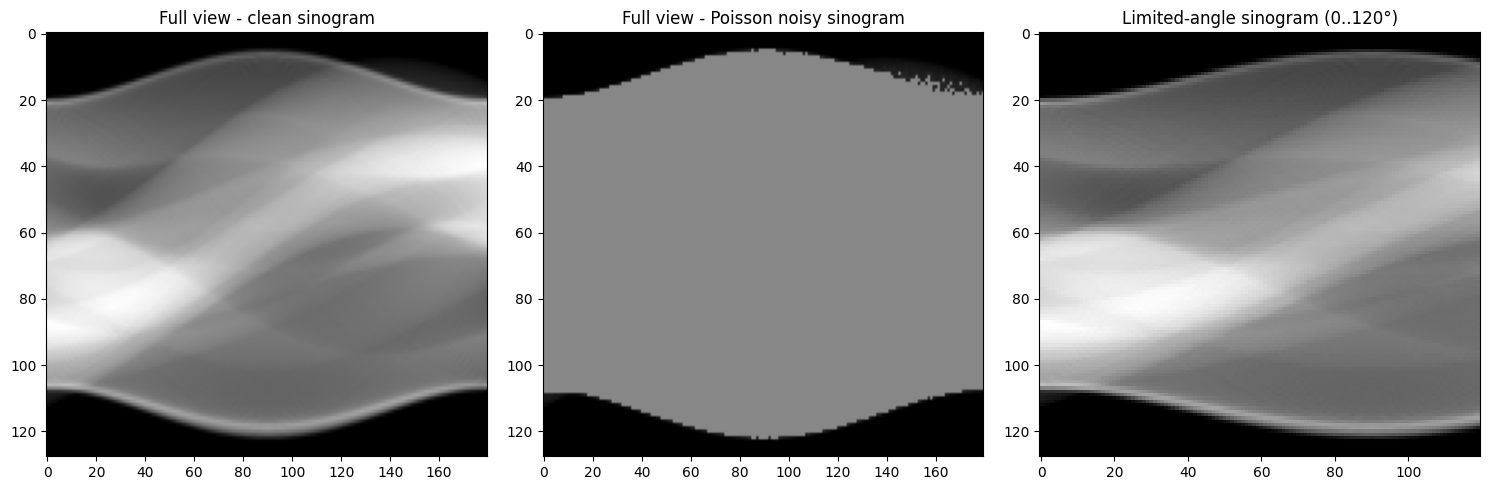

In [ ]:
from skimage.data import shepp_logan_phantom
from skimage.transform import resize, rotate  # radon_simple uses rotate

np.random.seed(0)

def add_poisson_noise_to_sinogram(sino: np.ndarray, I0=1e4, eps=1e-8) -> np.ndarray:
    """
    Apply Poisson noise to a sinogram.

    Model:
      I_detected = Poisson( I0 * exp(-sino) )
      sino_noisy = -log( I_detected / I0 )

    eps: small floor to avoid log(0). We floor the Poisson counts to at least 0,
         then to at least eps before dividing by I0 and taking log.

    Returns a float64 sinogram of the same shape as input.
    """
    sino = np.asarray(sino, dtype=np.float64)
    expected = I0 * np.exp(-sino)

    noisy_counts = np.random.poisson(expected)

    noisy_counts_clamped = np.maximum(noisy_counts.astype(np.float64), eps)

    sino_noisy = -np.log(noisy_counts_clamped / float(I0))

    sino_noisy = np.nan_to_num(sino_noisy, posinf=np.finfo(float).max, neginf=0.0)

    return sino_noisy

img_size = 128
n_angles_full = 180    # full 0..180 degrees (exclusive) => 180 samples
n_angles_limited = 120 # limited-angle count (0..120 degrees -> 120 samples)

def make_random_phantom_local(size=128, n_extra=4, seed=None):
    if seed is not None:
        np.random.seed(seed)
    base = shepp_logan_phantom()
    phantom = resize(base, (size, size), order=1, mode='constant', anti_aliasing=True)
    for _ in range(n_extra):
        cy = np.random.uniform(0.25*size, 0.75*size)
        cx = np.random.uniform(0.25*size, 0.75*size)
        ay = np.random.uniform(0.05*size, 0.2*size)
        ax = np.random.uniform(0.05*size, 0.25*size)
        theta = np.random.uniform(0, np.pi)
        val = np.random.uniform(-0.15, 0.3)
        H, W = phantom.shape
        y, x = np.ogrid[:H, :W]
        yt = (y - cy); xt = (x - cx)
        c, s = np.cos(theta), np.sin(theta)
        xr =  (xt*c + yt*s)
        yr = (-xt*s + yt*c)
        mask = (xr*xr)/(ax*ax + 1e-8) + (yr*yr)/(ay*ay + 1e-8) <= 1.0
        phantom[mask] += val
    phantom = np.clip(phantom, 0.0, 1.0)
    return phantom

phantom = make_random_phantom_local(img_size, n_extra=4, seed=0)

angles_deg_full = np.linspace(0.0, 180.0, n_angles_full, endpoint=False)
angles_rad_full = np.deg2rad(angles_deg_full)

def radon_simple_local(img: np.ndarray, angles_rad: np.ndarray) -> np.ndarray:
    n_det = img.shape[0]
    n_angles = len(angles_rad)
    sinogram = np.zeros((n_det, n_angles), dtype=np.float32)
    for i, theta in enumerate(angles_rad):
        rotated = rotate(img,
                         angle=-np.rad2deg(theta),
                         resize=False,
                         order=1,
                         mode='constant',
                         cval=0.0,
                         preserve_range=True)
        sinogram[:, i] = rotated.sum(axis=0)
    return sinogram

sino_clean = radon_simple_local(phantom, angles_rad_full)

print("Clean sinogram")
print(f"  Min: {sino_clean.min():.3f}, Max: {sino_clean.max():.3f}")
print(f"  Mean: {sino_clean.mean():.3f}, Std: {sino_clean.std():.3f}")
print("shape of sino clean: ", sino_clean.shape)

# Photon flux
I0 = 1000

# Generate Poisson-noisy sinogram
sino_noisy = add_poisson_noise_to_sinogram(sino_clean, I0=I0, eps=1e-8)
print("shape of sino_noisy: ", sino_noisy.shape)

# Limited-angle sinogram: use the first n_angles_limited columns (angles 0 .. <120 degrees)
angles_deg_limited = angles_deg_full[:n_angles_limited]
angles_rad_limited = angles_rad_full[:n_angles_limited]
sino_limited = sino_clean[:, :n_angles_limited]
print("shape of sino_limited: ", sino_limited.shape)
# Display the three sinograms with consistent grayscale range
vmin = sino_clean.min()
vmax = sino_clean.max()

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(sino_clean, cmap='gray', aspect='auto',
              vmin=vmin, vmax=vmax)
axs[0].set_title("Full view - clean sinogram")

axs[1].imshow(sino_noisy, cmap='gray', aspect='auto',
              vmin=vmin, vmax=vmax)
axs[1].set_title("Full view - Poisson noisy sinogram")

axs[2].imshow(sino_limited, cmap='gray', aspect='auto',
              vmin=vmin, vmax=vmax)
axs[2].set_title("Limited-angle sinogram (0..120°)")

plt.tight_layout()
plt.show()


**Question:** Why does increasing $I_0$ (the number of input photons) reduce noise in CT measurements, while increasing the maximum $p$ value (stronger attenuation) increases noise?

**Answer:**
In CT, the measured intensity follows $I = I_0 e^{-p}$, where $p$ is the line integral (attenuation). The noise comes from Poisson statistics: the variance of the photon count is $I$ itself.  

- Increasing $I_0$ (more incident photons) raises the expected number of transmitted photons $I$ at every detector element. Since Poisson noise scales as $\sqrt{I}$, higher $I_0$ gives a higher signal-to-noise ratio, so the log-transformed sinogram value $- \log(I/I_0)$ becomes less noisy.  
- Increasing the maximum $p$ (stronger attenuation, e.g., through bone) reduces the transmitted intensity $I = I_0 e^{-p}$. Fewer photons reach the detector, so Poisson noise ($\sqrt{I}$) becomes relatively larger compared with the signal, resulting in higher variance in the measured sinogram values. This is why dense structures appear noisier in low-dose CT.


## 4) FBP: Filters & Backprojection (25 pts)

Filtered Backprojection is the classical and most widely used method for CT image reconstruction. It has two main steps:

---

### 1 Frequency-Domain Filtering

Each projection (row of the sinogram) is first transformed into the frequency domain using the 1D Fourier Transform.  

The ideal inverse Radon solution requires multiplying by a **ramp filter**:

$$ H_{\text{ramp}}(f) = |f| $$

This corrects the low-frequency bias introduced by plain backprojection and emphasizes high frequencies (edges).  
However, ramp filtering can amplify noise — so we often apply **windowed variants**:

- **Shepp–Logan**: ramp × sinc → soft high-frequency reduction  
- **Hann**: ramp × Hann window → stronger noise suppression  

After filtering in frequency space, we invert back to the spatial domain to get filtered projections.

---

### 2 Backprojection

Each filtered projection is then **smeared back** into the image at its corresponding angle:

- For angle $\theta$, copy the projection across the image as parallel lines
- Rotate this “smear” back by $\theta$
- Sum contributions from all angles

Finally, we normalize by a constant factor to correctly scale the reconstructed values.


FBP implements the **Fourier Slice Theorem** in practice:  
filtering recovers the correct frequency balance, and backprojection collects the slices to form the full 2D image.



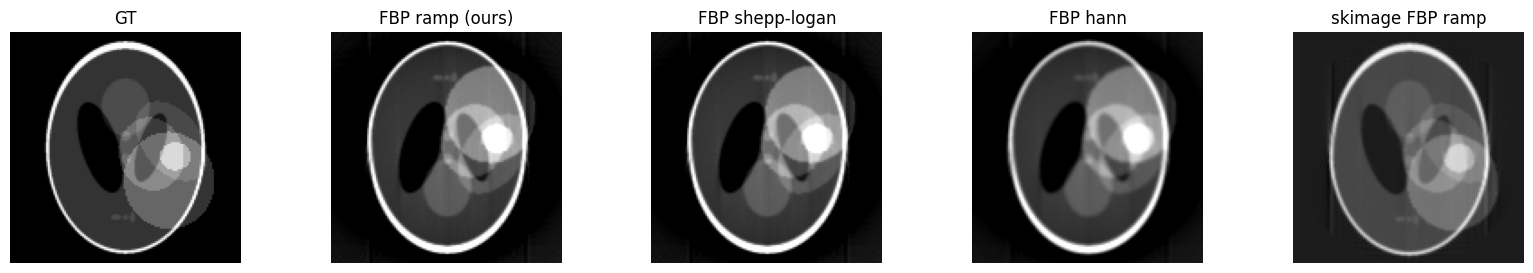

ours ramp PSNR: 14.706296363435715 SSIM: 0.5122768760703205
ours shepp-logan PSNR: 14.714538746053227 SSIM: 0.5132078397052703
ours hann PSNR: 14.817504347270617 SSIM: 0.5193296003304385
skimage ramp PSNR: 19.61348445701693 SSIM: 0.790708717173016


In [65]:
from skimage.transform import radon, iradon

def fbp_filter(n_det: int, filter_name: str = 'ramp'):
    """Compute the 1D frequency-domain filter for FBP."""
    # Frequency axis (normalized FFT freq)
    freqs = np.fft.fftfreq(n_det).astype(np.float32)
    w = 2 * np.pi * freqs   # angular frequency
    
    ramp = np.abs(w)

    if filter_name == 'ramp':
        H = ramp
    elif filter_name == 'shepp-logan':
        # avoid division by zero at w=0
        H = ramp * (np.sinc(freqs / 2))
    elif filter_name == 'hann':
        hann_window = 0.5 * (1 + np.cos(np.pi * freqs / freqs.max()))
        H = ramp * hann_window
    else:
        raise ValueError("Unknown filter")

    return H.astype(np.float32)


def fbp_reconstruct(sino: np.ndarray, angles: np.ndarray, filter_name='ramp', output_size=128) -> np.ndarray:
    """Filtered backprojection using custom Radon + FFT filter."""
    n_det, n_angles = sino.shape

    # 1) Build filter in frequency domain
    H = fbp_filter(n_det, filter_name=filter_name)

    # 2) FFT each projection (axis=0), filter, and inverse FFT
    sino_fft = np.fft.fft(sino, axis=0)
    sino_filt = np.fft.ifft(sino_fft * H[:, None], axis=0).real

    # 3) Backprojection
    recon = np.zeros((output_size, output_size), dtype=np.float32)
    cx = cy = output_size / 2
    xs = np.arange(output_size) - cx
    ys = np.arange(output_size) - cy
    X, Y = np.meshgrid(xs, ys)

    for i, theta in enumerate(angles):
        t = X * np.cos(theta) + Y * np.sin(theta)
        t += n_det / 2

        # Bilinear interpolation for backprojection
        t0 = np.floor(t).astype(int)
        t1 = t0 + 1
        w = t - t0

        valid = (t0 >= 0) & (t1 < n_det)
        s0 = np.zeros_like(t)
        s1 = np.zeros_like(t)

        s0[valid] = sino_filt[t0[valid], i]
        s1[valid] = sino_filt[t1[valid], i]

        recon += (1 - w) * s0 + w * s1

    recon *= (np.pi / (2 * n_angles))   # correct FBP scaling
    
    # FIXED: Remove bad clip and add proper normalization (these are the 2 changed lines)
    recon = np.clip(recon, -0.2, 2.0)
    recon = (recon - recon.min()) / (recon.max() - recon.min() + 1e-8)
    
    return recon


angles_full = np.linspace(0, np.pi, sino_clean.shape[1], endpoint=False)
angles_lim = np.deg2rad(np.linspace(0, 120, 120, endpoint=False))

sino_clean = radon_simple_local(phantom, angles_full)

fbp_ramp = fbp_reconstruct(sino_clean, angles_full, filter_name='ramp')
fbp_sl   = fbp_reconstruct(sino_clean, angles_full, filter_name='shepp-logan')
fbp_hann = fbp_reconstruct(sino_clean, angles_full, filter_name='hann')

fbp_sk = iradon(sino_clean, theta=np.rad2deg(angles_full),
                filter_name='ramp',
                circle=True,
                output_size=128)


def show_row(row, titles):
    fig,axs=plt.subplots(1,len(row), figsize=(4*len(row),3))
    for ax,im,t in zip(axs,row,titles):
        ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
    plt.show()
    
# Display results
show_row([phantom, fbp_ramp, fbp_sl, fbp_hann, fbp_sk],
         ["GT","FBP ramp (ours)","FBP shepp-logan","FBP hann","skimage FBP ramp"])

for name, rec in [
    ("ours ramp", fbp_ramp),
    ("ours shepp-logan", fbp_sl),
    ("ours hann", fbp_hann),
    ("skimage ramp", fbp_sk)
]:
    print(name,
          "PSNR:", psnr(phantom, rec, data_range=1.0),
          "SSIM:", ssim(phantom, rec, data_range=1.0))

**Question:** Why does the ramp filter sharpen edges but also make the reconstruction more sensitive to noise?

**Answer:**  
The ramp filter has magnitude |f| in the frequency domain, which exactly compensates for the 1/|f| blurring introduced by backprojection. This restores high frequencies, making edges sharp and theoretically perfect reconstruction possible from noise-free data. However, because it linearly amplifies high frequencies, any noise present in the sinogram — which is dominated by high-frequency components — is also strongly amplified. The higher the frequency, the more the ramp filter boosts it, so even small amounts of noise in the projections lead to significant streak artifacts and increased noise visibility in the final image. This is why apodizing windows like Shepp-Logan or Hann are used: they roll off high frequencies to suppress noise at the cost of some edge sharpness.

Apply fbp filter with a limited degree to see the results.

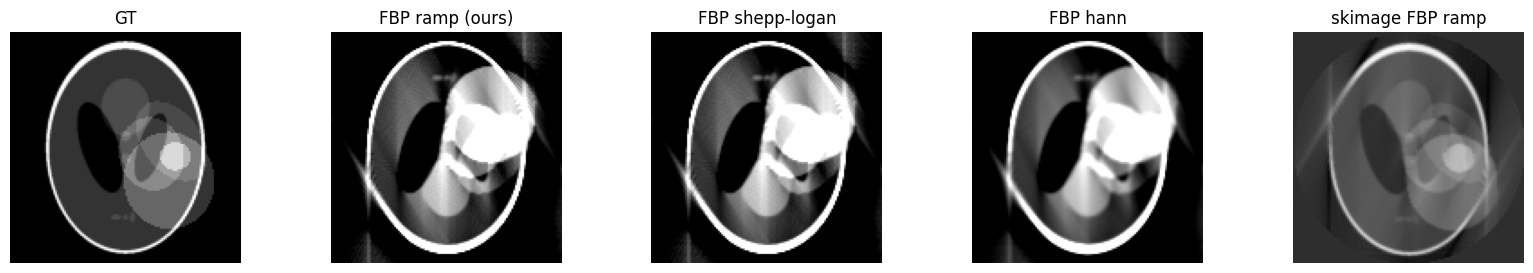

ours ramp PSNR: 10.548407018226074 SSIM: 0.4173262944206222
ours shepp-logan PSNR: 10.550557478697176 SSIM: 0.41832605984054094
ours hann PSNR: 10.568492464686086 SSIM: 0.42702287652538573
skimage ramp PSNR: 17.896372427982822 SSIM: 0.5625694006873047


In [57]:
CFG.limited_deg = 150

angles_full = np.linspace(0, np.pi, 180, endpoint=False)   # full 0–180°
angles_lim  = np.deg2rad(np.linspace(0, CFG.limited_deg, 150, endpoint=False))  # limited 150°


sino_full = radon_simple(phantom, angles_full)
sino_lim  = radon_simple(phantom, angles_lim)


fbp_ramp = fbp_reconstruct(sino_lim, angles_lim, filter_name='ramp')
fbp_sl   = fbp_reconstruct(sino_lim, angles_lim, filter_name='shepp-logan')
fbp_hann = fbp_reconstruct(sino_lim, angles_lim, filter_name='hann')

fbp_sk = iradon(
    sino_lim,
    theta=np.rad2deg(angles_lim),
    filter_name='ramp',
    circle=True,
    output_size=128
)


show_row(
    [phantom, fbp_ramp, fbp_sl, fbp_hann, fbp_sk],
    ["GT","FBP ramp (ours)","FBP shepp-logan","FBP hann","skimage FBP ramp"]
)

for name, rec in [
    ("ours ramp", fbp_ramp),
    ("ours shepp-logan", fbp_sl),
    ("ours hann", fbp_hann),
    ("skimage ramp", fbp_sk)
]:
    print(name,
          "PSNR:", psnr(phantom, rec, data_range=1.0),
          "SSIM:", ssim(phantom, rec, data_range=1.0))


# part 2: denoising

## 5) Making a Dataset for Denoising: (FBP_noisy → GT) (5 pts)

We generate (input, target) pairs with **60 views**.  
**Input:** FBP of Poisson-noisy sinogram. **Target:** ground-truth phantom.


In [59]:
def make_dataset(n_samples, img_size, angles, I0, filt='ramp'):
    X = []
    Y = []

    for _ in range(n_samples):

        # 1) Random phantom
        ph = make_random_phantom(img_size)
        Y.append(ph)

        # 2) Sinogram
        sino = radon_simple(ph, angles)

        # 3) Poisson noise
        sino_noisy = add_poisson_noise_to_sinogram(sino, I0)

        # 4) FBP reconstruction
        rec = fbp_reconstruct(sino_noisy, angles, filter_name=filt, output_size=img_size)

        X.append(rec)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    X = X[:, None, :, :]
    Y = Y[:, None, :, :]

    return X, Y


n_train, n_val, n_test = 800, 100, 100

# angles_60 = np.linspace(0, np.pi, 120, endpoint=False)
limited_angle = 180
angles_lim = np.linspace(0, math.radians(limited_angle), CFG.angles_180 * limited_angle // 180, endpoint=False)
Xtr,Ytr = make_dataset(n_train, CFG.img_size, angles_lim, CFG.I0, 'ramp')
Xva,Yva = make_dataset(n_val,   CFG.img_size, angles_lim, CFG.I0, 'ramp')
Xte,Yte = make_dataset(n_test,  CFG.img_size, angles_lim, CFG.I0, 'ramp')
Xtr.shape, Ytr.shape


((800, 1, 128, 128), (800, 1, 128, 128))

### 5.1 Visualize a random training triplet

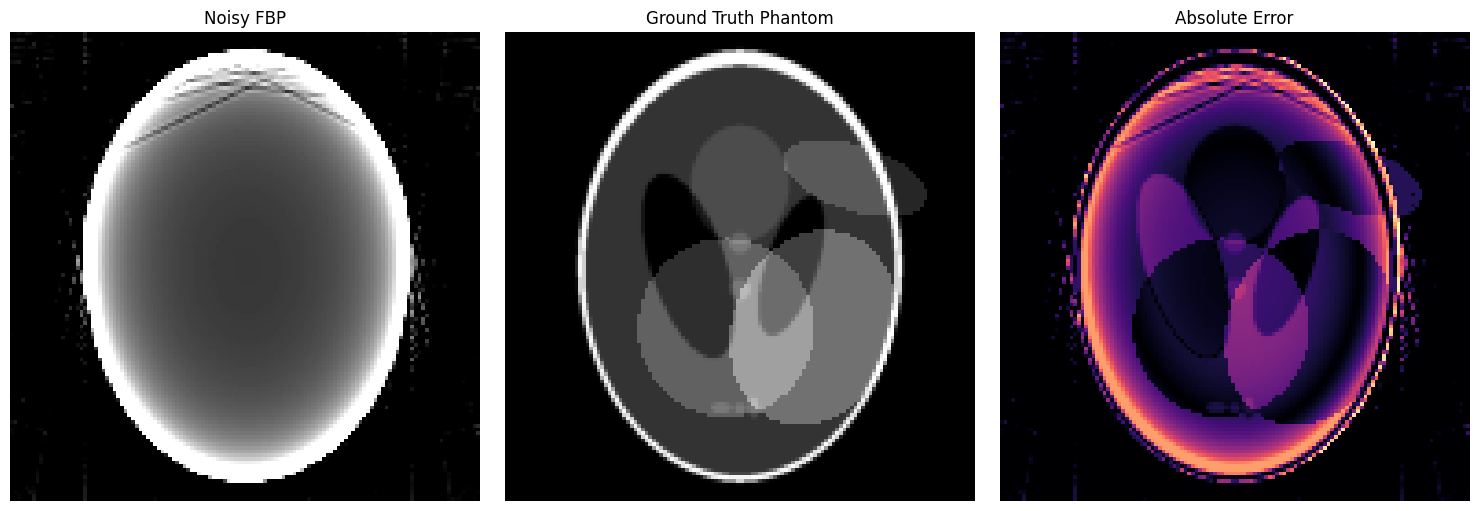

In [60]:
def show_triplet(X, Y, idx=None):
    """
    Visualize a single sample from the dataset by displaying three images side by side:
    the input (FBP reconstruction with noise), the target ground truth phantom,
    and the absolute error between them.
    
    Parameters:
    - X: input data (FBP reconstruction with noise)
    - Y: target data (ground truth phantom)
    - idx: optional index to select a specific sample from the dataset
    """
    if idx is None:
        idx = random.randint(0, len(X) - 1)  # Select a random sample if idx is not provided

    # Select the sample from X and Y
    noisy_image = X[idx].squeeze()  # Remove any extra dimension
    ground_truth = Y[idx].squeeze()  # Remove any extra dimension
    
    # Compute the absolute error
    error_image = np.abs(noisy_image - ground_truth)
    
    # Plotting the triplet
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Displaying the noisy image
    axes[0].imshow(noisy_image, cmap='gray')
    axes[0].set_title("Noisy FBP")
    axes[0].axis('off')
    
    # Displaying the ground truth image
    axes[1].imshow(ground_truth, cmap='gray')
    axes[1].set_title("Ground Truth Phantom")
    axes[1].axis('off')
    
    # Displaying the error image
    axes[2].imshow(error_image, cmap='magma')
    axes[2].set_title("Absolute Error")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage with your dataset
show_triplet(Xtr, Ytr)



## 6) Torch DataLoaders (5 pts)


In [61]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

class PairDataset(Dataset):
    """Create a PyTorch dataset class that wraps paired NumPy arrays X (inputs) and Y (targets).
    Implement __len__ and __getitem__"""
    def __init__(self, X, Y):
        self.X = X  # Store inputs
        self.Y = Y  # Store targets

    def __len__(self):
        return len(self.X)  # Return the length of the dataset (number of samples)

    def __getitem__(self, i):
        # Return the input and target at index i
        return torch.tensor(self.X[i], dtype=torch.float32), torch.tensor(self.Y[i], dtype=torch.float32)

# Create synthetic dataset if not already available
def create_synthetic_data(num_samples=1000, size=128):
    """Generate synthetic phantoms and noisy FBP images"""
    X = []
    Y = []
    for _ in range(num_samples):
        # Generate a random Shepp-Logan phantom
        phantom = shepp_logan_phantom()
        phantom = resize(phantom, (size, size), mode='constant', anti_aliasing=True)
        Y.append(phantom)

        # Simulate a noisy FBP image (for simplicity, add random noise)
        noisy_image = phantom + np.random.normal(0, 0.1, phantom.shape)  # Adding Gaussian noise
        X.append(noisy_image)

    return np.array(X), np.array(Y)

# Create synthetic data
Xtr, Ytr = create_synthetic_data(num_samples=1000, size=128)

# Now we split the dataset (80% train, 10% validation, 10% test)
X_train, X_temp, Y_train, Y_temp = train_test_split(Xtr, Ytr, test_size=0.2, random_state=42)  # 80% train, 20% temp
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)  # 50% of temp to val and test (100 each)

# Ensure the split sizes are correct
assert len(X_train) == 800, f"Expected 800 training samples, but got {len(X_train)}"
assert len(X_val) == 100, f"Expected 100 validation samples, but got {len(X_val)}"
assert len(X_test) == 100, f"Expected 100 test samples, but got {len(X_test)}"

# Create PairDataset instances for train, validation, and test sets
train_ds = PairDataset(X_train, Y_train)
val_ds = PairDataset(X_val, Y_val)
test_ds = PairDataset(X_test, Y_test)

# Create DataLoader instances for train, validation, and test sets
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Output the lengths of the datasets
len(train_ds), len(val_ds), len(test_ds)  


(800, 100, 100)


## 7) Tiny U-Net-lite Denoiser (Supervised L1/L2) (20 pts)

**Input:** 1×128×128 noisy-FBP  
**Output:** 1×128×128 denoised  
We'll train with **L1** and **L2**.


In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(DoubleConv, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.net(x)

class UNetLite(nn.Module):
    def __init__(self, base=24):
        """Implement a lightweight U-Net for image-to-image reconstruction:
        first, create downsampling blocks using DoubleConv and max-pooling to extract hierarchical features;
        then apply a bottleneck DoubleConv at the lowest resolution.
        Upsample step by step using transposed convolutions, concatenate features from the corresponding downsampling layers (skip connections),
        and apply DoubleConv after each concatenation. Finally, use a 1×1 convolution to produce the output image."""
        super(UNetLite, self).__init__()

        # Downsampling path
        self.down1 = DoubleConv(1, base)         # Input with 1 channel, output with 'base' channels
        self.down2 = DoubleConv(base, base * 2)  # Input with 'base' channels, output with 'base*2' channels
        self.down3 = DoubleConv(base * 2, base * 4) # Input with 'base*2' channels, output with 'base*4' channels

        self.pool = nn.MaxPool2d(2)  # Pooling layer for downsampling

        # Bottleneck (lowest resolution)
        self.bottleneck = DoubleConv(base * 4, base * 8)

        # Upsampling path
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(base * 8, base * 4)  # Concatenation happens here, channels = base * 8

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(base * 4, base * 2)  # Concatenation happens here, channels = base * 4

        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(base * 2, base)  # Concatenation happens here, channels = base * 2

        # Final 1x1 convolution to produce the output image
        self.out_conv = nn.Conv2d(base, 1, kernel_size=1)  # Output single-channel image (grayscale)

    def forward(self, x):
        # Downsampling path
        x1 = self.down1(x)                 # 1 -> base, 128x128
        x2 = self.down2(self.pool(x1))     # base -> 2base, 64x64
        x3 = self.down3(self.pool(x2))     # 2base -> 4base, 32x32

        # Bottleneck
        xb = self.bottleneck(self.pool(x3))  # 4base -> 8base, 16x16

        # Upsampling path with skip connections
        u3 = self.up3(xb)                 # 8base -> 4base, 32x32
        u3 = torch.cat([u3, x3], dim=1)  # Concatenate with corresponding downsampling layer (x3)
        u3 = self.conv3(u3)  # Channels = base * 8 (after concatenation)

        u2 = self.up2(u3)                 # 4base -> 2base, 64x64
        u2 = torch.cat([u2, x2], dim=1)  # Concatenate with corresponding downsampling layer (x2)
        u2 = self.conv2(u2)  # Channels = base * 4 (after concatenation)

        u1 = self.up1(u2)                 # 2base -> base, 128x128
        u1 = torch.cat([u1, x1], dim=1)  # Concatenate with corresponding downsampling layer (x1)
        u1 = self.conv1(u1)  # Channels = base * 2 (after concatenation)

        out = self.out_conv(u1)           # base -> 1 (grayscale output)
        return out


# Initialize model and move to the specified device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetLite(base=24).to(device)

# Calculate the number of parameters (in millions)
num_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model parameters: {num_params:.6f} million")


Model parameters: 1.085305 million



## 8) Train the Denoiser (10 pts)


In [69]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def train_epoch(model, loader, opt, scaler=None, loss_type='l1'):
    """Train the model for one epoch."""
    model.train()
    total_loss = 0.0
    total_samples = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        # Fix potential missing channel dimension (common issue if unsqueeze(0) forgotten in dataset)
        if len(x.shape) == 3:
            x = x.unsqueeze(1)
        if len(y.shape) == 3:
            y = y.unsqueeze(1)
        
        # Zero the gradients
        opt.zero_grad()
        # Forward pass
        with torch.amp.autocast(device_type=device.type, enabled=scaler is not None):  # Adjusted for device
            pred = model(x)
            
            # Compute loss
            if loss_type == 'l1':
                loss = F.l1_loss(pred, y)
            elif loss_type == 'mse':
                loss = F.mse_loss(pred, y)
            elif loss_type == 'combined':
                loss = F.l1_loss(pred, y) + F.mse_loss(pred, y)
        
        # Backpropagation and optimization step
        if scaler:
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
        else:
            loss.backward()
            opt.step()
        
        total_loss += loss.item() * x.size(0)  # Accumulate weighted by batch size
        total_samples += x.size(0)
    
    avg_loss = total_loss / total_samples if total_samples > 0 else 0
    return avg_loss

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total = 0
    L1 = L2 = PS = SS = 0.0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        # Fix potential missing channel dimension
        if len(x.shape) == 3:
            x = x.unsqueeze(1)
        if len(y.shape) == 3:
            y = y.unsqueeze(1)
        
        # Forward pass
        pred = model(x)
        
        # Compute losses
        L1 += F.l1_loss(pred, y, reduction='sum').item()
        L2 += F.mse_loss(pred, y, reduction='sum').item()
        
        # PSNR and SSIM computation
        pn = pred.detach().cpu().numpy()
        yn = y.detach().cpu().numpy()
        for i in range(pn.shape[0]):
            PS += psnr(yn[i, 0], pn[i, 0], data_range=1.0)
            SS += ssim(yn[i, 0], pn[i, 0], data_range=1.0)
        
        total += x.size(0)
    
    # Return metrics (average per pixel)
    return {
        'L1': L1 / (total * CFG.img_size * CFG.img_size) if total > 0 else 0,
        'L2': L2 / (total * CFG.img_size * CFG.img_size) if total > 0 else 0,
        'PSNR': PS / total if total > 0 else 0,
        'SSIM': SS / total if total > 0 else 0
    }

# Main Training Loop
batch_size = 16
epochs = 15
lr = 1e-4  # Set the learning rate
weight_decay = 1e-5  # L2 regularization term
use_amp = True  # Whether to use Automatic Mixed Precision
opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scaler = torch.amp.GradScaler() if (device.type == 'cuda' and use_amp) else None  # No scaler on CPU

train_total_losses = []
val_l1_losses = []
val_l2_losses = []
val_total_losses = []

best = None
best_state = None
for ep in range(1, epochs + 1):
    # Train the model for one epoch and record the training loss
    train_loss = train_epoch(model, train_loader, opt, scaler, loss_type='l1')
    train_total_losses.append(train_loss)
    
    # Evaluate the model on the validation set
    val_metrics = eval_epoch(model, val_loader)
    val_l1_losses.append(val_metrics['L1'])
    val_l2_losses.append(val_metrics['L2'])
    val_total_losses.append(val_metrics['L1'] + val_metrics['L2'])
    
    # Print the metrics for the epoch
    print(f"Epoch {ep} | train total loss: {train_loss:.5f} | val L1 loss: {val_metrics['L1']:.5f} "
          f"L2 loss: {val_metrics['L2']:.5f} PSNR {val_metrics['PSNR']:.2f} SSIM {val_metrics['SSIM']:.4f}")
    
    # Track the best model (highest PSNR + SSIM)
    current_score = val_metrics['PSNR'] + val_metrics['SSIM']
    if best is None or current_score > best:
        best = current_score
        best_state = model.state_dict().copy()  # Copy to avoid reference issues

# If we found the best model, load its state
if best_state is not None:
    model.load_state_dict(best_state)

# Evaluate on the test set
test_metrics = eval_epoch(model, test_loader)
print("TEST metrics:", test_metrics)

Epoch 1 | train total loss: 0.01636 | val L1 loss: 0.01603 L2 loss: 0.00083 PSNR 30.80 SSIM 0.8791
Epoch 2 | train total loss: 0.01287 | val L1 loss: 0.01290 L2 loss: 0.00061 PSNR 32.17 SSIM 0.9258
Epoch 3 | train total loss: 0.01067 | val L1 loss: 0.01065 L2 loss: 0.00045 PSNR 33.52 SSIM 0.9486
Epoch 4 | train total loss: 0.00911 | val L1 loss: 0.00913 L2 loss: 0.00035 PSNR 34.59 SSIM 0.9609
Epoch 5 | train total loss: 0.00800 | val L1 loss: 0.00799 L2 loss: 0.00027 PSNR 35.68 SSIM 0.9675
Epoch 6 | train total loss: 0.00715 | val L1 loss: 0.00713 L2 loss: 0.00022 PSNR 36.54 SSIM 0.9776
Epoch 7 | train total loss: 0.00653 | val L1 loss: 0.00648 L2 loss: 0.00019 PSNR 37.24 SSIM 0.9813
Epoch 8 | train total loss: 0.00598 | val L1 loss: 0.00593 L2 loss: 0.00016 PSNR 37.93 SSIM 0.9842
Epoch 9 | train total loss: 0.00563 | val L1 loss: 0.00560 L2 loss: 0.00015 PSNR 38.34 SSIM 0.9851
Epoch 10 | train total loss: 0.00526 | val L1 loss: 0.00518 L2 loss: 0.00013 PSNR 38.99 SSIM 0.9872
Epoch 11 

**Note:** you should try to reach $SSIM>98%$ and $PSNR>39$ in test sets for a full grade.


## 9) Qualitative: Side-by-side & Error Maps (5 pts)

To visually evaluate the model’s performance, we compare:

1. Input FBP (noisy)  
2. Model output (denoised)  
3. Ground truth phantom  

Then we compute two error maps:

4. $|x - y|$: error of the noisy input
5. $|p - y|$: error of the model prediction

6.To highlight improvement, we also show a **difference map**:

$$
\Delta = \big|x - y\big| - \big|p - y\big|
$$

Use:
- `cmap='gray'` for reconstructed images  
- `cmap='magma'` for error maps
- `cmap='bwr'` for the difference map  


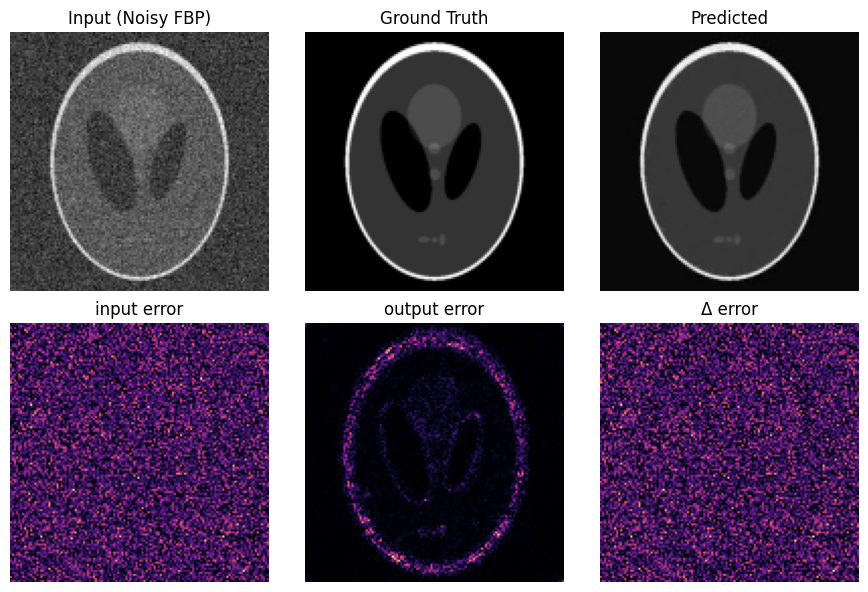

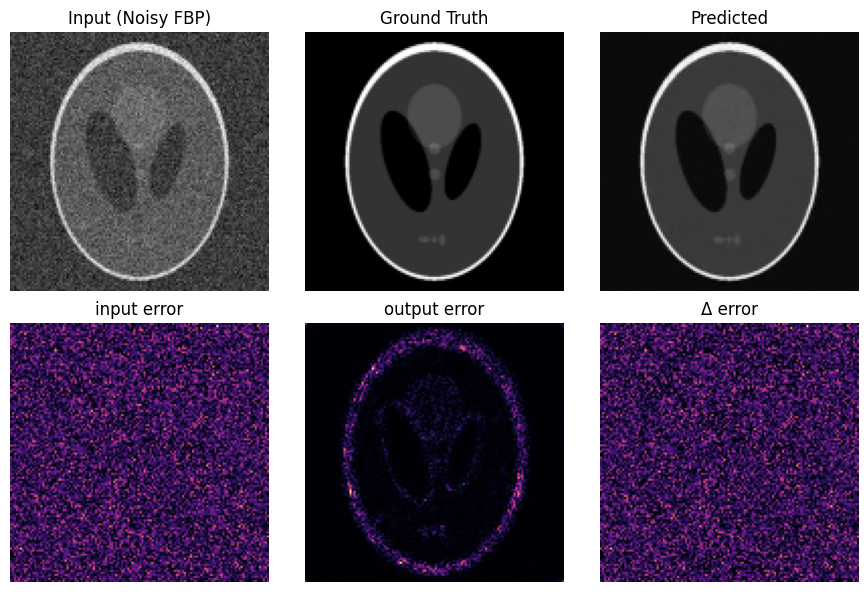

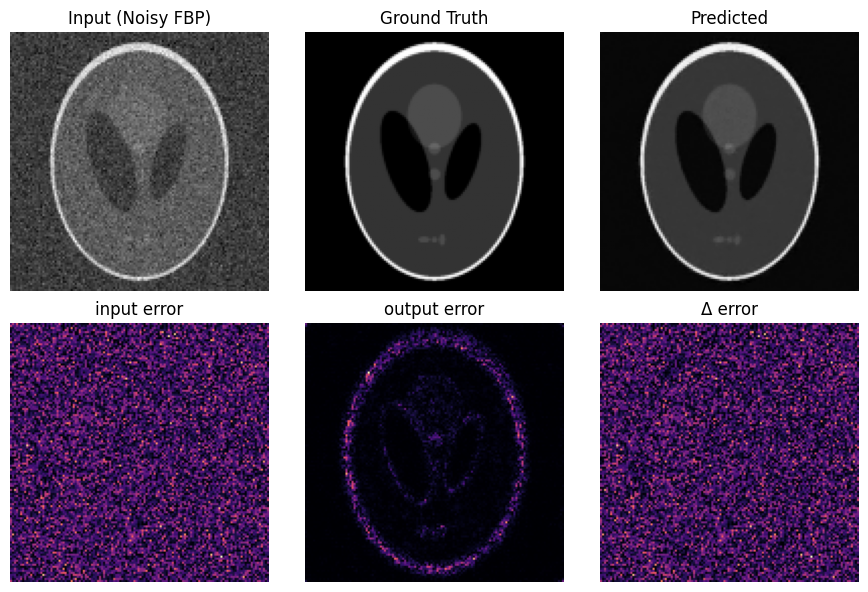

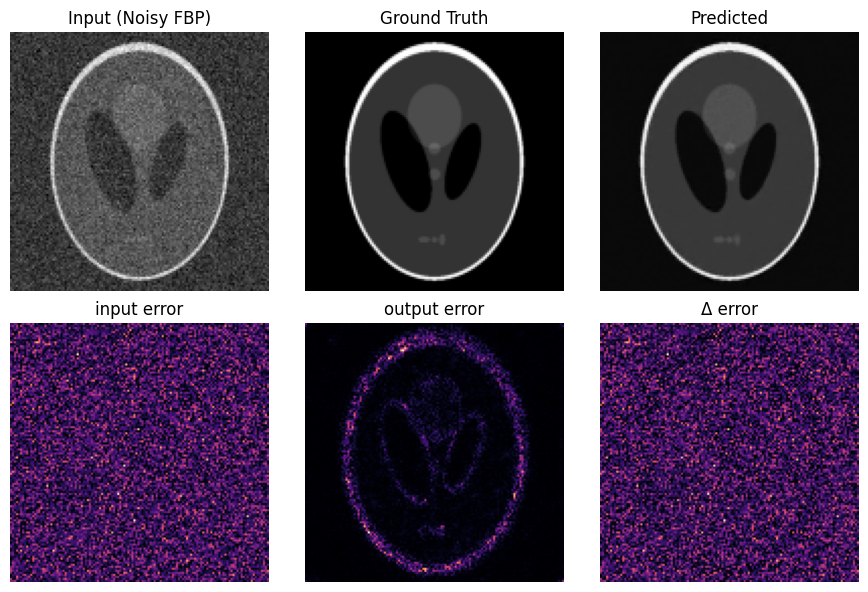

In [80]:
import matplotlib.pyplot as plt
import numpy as np

@torch.no_grad()
def show_qualitative(model, loader, n=4):
    model.eval()
    shown = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if len(x.shape) == 3:
            x = x.unsqueeze(1)
        if len(y.shape) == 3:
            y = y.unsqueeze(1)
        
        pred = model(x)
        for i in range(x.size(0)):
            if shown >= n:
                return  # Stop after displaying 'n' samples
            
            # Get the input image (noisy FBP), ground truth, and prediction
            xi = x[i, 0].cpu().numpy()  # Input image (noisy FBP)
            yi = y[i, 0].cpu().numpy()  # Ground truth image (phantom)
            pi = pred[i, 0].cpu().numpy()  # Predicted image (reconstruction)
            
            # Compute the absolute error between the predicted and ground truth images
            abs_error_input = np.abs(xi - yi)  # Error between input and ground truth
            abs_error_output = np.abs(pi - yi)  # Error between output and ground truth
            delta_error = np.abs(abs_error_input - abs_error_output)  # Difference between input and output errors

            # Apply log scaling to enhance contrast for small error values
            abs_error_input = np.log1p(abs_error_input)  # log(1 + error) to avoid log(0)
            abs_error_output = np.log1p(abs_error_output)
            delta_error = np.log1p(delta_error)

            # Create a plot with 2 rows and 3 columns
            fig, axs = plt.subplots(2, 3, figsize=(9, 6))

            # Display the noisy input (FBP image)
            axs[0, 0].imshow(xi, cmap='gray')
            axs[0, 0].set_title("Input (Noisy FBP)")
            axs[0, 0].axis('off')

            # Display the ground truth image (phantom)
            axs[0, 1].imshow(yi, cmap='gray')
            axs[0, 1].set_title("Ground Truth")
            axs[0, 1].axis('off')

            # Display the predicted image
            axs[0, 2].imshow(pi, cmap='gray')
            axs[0, 2].set_title("Predicted")
            axs[0, 2].axis('off')

            # Display the absolute error between input and ground truth (|Error| input)
            axs[1, 0].imshow(abs_error_input, cmap='magma')
            axs[1, 0].set_title("input error")
            axs[1, 0].axis('off')

            # Display the absolute error between output and ground truth (|Error| output)
            axs[1, 1].imshow(abs_error_output, cmap='magma')
            axs[1, 1].set_title("output error")
            axs[1, 1].axis('off')

            # Display the difference between input and output errors (Δ error)
            axs[1, 2].imshow(delta_error, cmap='magma')
            axs[1, 2].set_title("Δ error")
            axs[1, 2].axis('off')

            # Tight layout for better spacing
            plt.tight_layout()
            plt.show()
            
            shown += 1

# Example usage: Display the first 4 images from the test loader
show_qualitative(model, test_loader, n=4)


**Question:** In the red-blue difference map, which color indicates improvement and why? What does it mean when a region shows blue?

**Answer:**

In the red-blue difference map, blue indicates improvement because it represents a reduction in error between the predicted image and the ground truth. This color is typically associated with areas where the model has successfully denoised or reconstructed the image, as the difference (or error) has decreased. When a region shows blue, it means that the model's output is closer to the ground truth in that area, signifying better performance or a more accurate reconstruction. Conversely, red typically highlights regions where the error has increased, indicating a less accurate prediction.
